<a href="https://colab.research.google.com/github/DhanshreeRaut/Pattern-Recognition/blob/main/Practical_4_CM23059.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Install required library (if needed)
!pip install openpyxl -q


In [6]:
# Import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt


In [7]:
# -------------------------------
# Upload Dataset
# -------------------------------

from google.colab import files

uploaded = files.upload()

# Read dataset
df = pd.read_excel(next(iter(uploaded)))

# Display first rows
print("First 5 Rows")
display(df.head())

print("\nDataset Shape:", df.shape)


Saving Copy of loan.xlsx to Copy of loan (2).xlsx
First 5 Rows


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y



Dataset Shape: (614, 13)


In [10]:
# -------------------------------
# Data Preprocessing
# -------------------------------

# Remove Loan_ID if present
if 'Loan_ID' in df.columns:
    df = df.drop('Loan_ID', axis=1)

# Fill missing values
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

# Convert every categorical column to string first
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str)
        df[col] = le.fit_transform(df[col])

# If any column still has mixed values, convert it too
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str)
        df[col] = LabelEncoder().fit_transform(df[col])

# Features and Target
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

In [11]:
# -------------------------------
# Split Dataset
# -------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
# -------------------------------
# Standardization (Required for KNN)
# -------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [13]:
# ==========================================
# Decision Tree Classifier
# ==========================================

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("\n========== Decision Tree ==========")

print("Accuracy:",
      accuracy_score(y_test, dt_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, dt_pred))

print("\nClassification Report")
print(classification_report(y_test, dt_pred))



========== Decision Tree ==========
Accuracy: 0.6910569105691057

Confusion Matrix
[[23 20]
 [18 62]]

Classification Report
              precision    recall  f1-score   support

           0       0.56      0.53      0.55        43
           1       0.76      0.78      0.77        80

    accuracy                           0.69       123
   macro avg       0.66      0.65      0.66       123
weighted avg       0.69      0.69      0.69       123



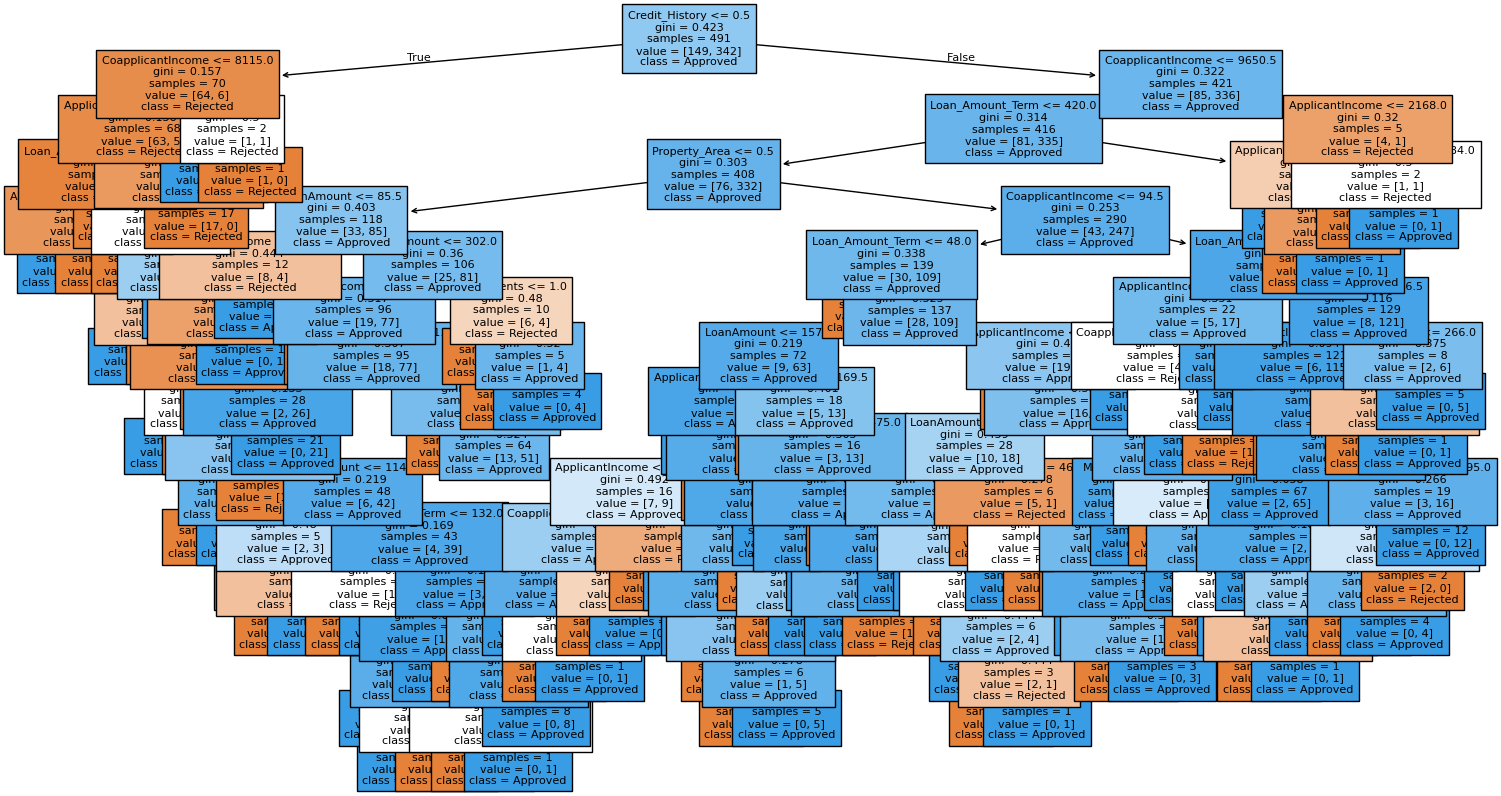

In [14]:
# -------------------------------
# Plot Decision Tree
# -------------------------------

plt.figure(figsize=(18,10))

plot_tree(
    dt,
    feature_names=X.columns,
    class_names=["Rejected","Approved"],
    filled=True,
    fontsize=8
)

plt.show()

In [15]:

# ==========================================
# K-Nearest Neighbors
# ==========================================

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

knn_pred = knn.predict(X_test_scaled)

print("\n========== KNN ==========")

print("Accuracy:",
      accuracy_score(y_test, knn_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, knn_pred))

print("\nClassification Report")
print(classification_report(y_test, knn_pred))

# ==========================================
# Feature Importance (Decision Tree)
# ==========================================

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance")
display(importance)



========== KNN ==========
Accuracy: 0.7560975609756098

Confusion Matrix
[[17 26]
 [ 4 76]]

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.40      0.53        43
           1       0.75      0.95      0.84        80

    accuracy                           0.76       123
   macro avg       0.78      0.67      0.68       123
weighted avg       0.77      0.76      0.73       123


Feature Importance


,Feature,Importance
9,Credit_History,0.293493
5,ApplicantIncome,0.244570
7,LoanAmount,0.172321
6,CoapplicantIncome,0.098029
2,Dependents,0.050823
8,Loan_Amount_Term,0.046094
1,Married,0.032243
10,Property_Area,0.029587
4,Self_Employed,0.014453
3,Education,0.011291


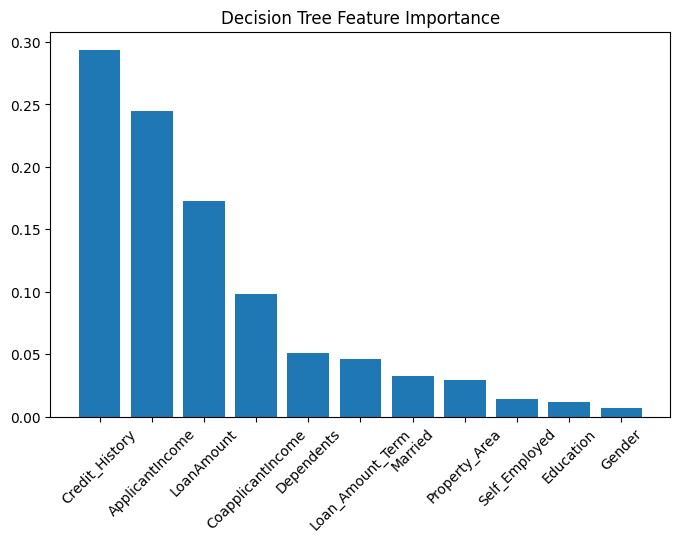

In [16]:
# Plot Feature Importance

plt.figure(figsize=(8,5))

plt.bar(
    importance['Feature'],
    importance['Importance']
)

plt.xticks(rotation=45)

plt.title("Decision Tree Feature Importance")

plt.show()